### **EDA** (Exploratory Data Analysis)
Objective: Understand the clean data behaviour, identifies patterns and get insights that answers the the project central question
> *Which factors are associated to a bigger probability of a patient don't shows up in a schedule attendance ?*

**Input:** `../data/processed/appointments_clean.csv` (created by `01_etl.ipynb`)

In [23]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
%matplotlib inline 

## Setting Paths

In [24]:
DATAPATH = "../data/processed"
DATAFILE_NAME = os.path.join(DATAPATH, "appointments_clean.csv")
data = pd.read_csv(DATAFILE_NAME)
display(data)
print(f"Shape: {data.shape}")

,Unnamed: 0,specialty,appointment_time,gender,appointment_date,no_show,no_show_reason,disability,entry_service_date,city,...,appointment_month,appointment_year,appointment_shift,age,under_12_years_old,over_60_years_old,patient_needs_companion,rain_intensity,heat_intensity,icd_description
0,0,physiotherapy,13:20,M,2021-09-09,1,surto,NaN,NaN,NaN,...,sept,2021,afternoon,NaN,0,0,0,no_rain,mild,NaN
1,1,psychotherapy,13:20,M,2021-09-09,0,NaN,NaN,NaN,NaN,...,sept,2021,afternoon,NaN,0,0,0,no_rain,mild,NaN
2,2,speech therapy,13:20,F,2021-09-09,0,NaN,NaN,NaN,NaN,...,sept,2021,afternoon,NaN,0,0,0,no_rain,mild,NaN
3,3,physiotherapy,13:20,F,2021-09-09,0,NaN,NaN,NaN,NaN,...,sept,2021,afternoon,NaN,0,0,0,no_rain,mild,NaN
4,4,physiotherapy,14:00,M,2021-09-09,0,NaN,motor,2020-02-05,B. CAMBORIU,...,sept,2021,afternoon,68.0,0,1,1,no_rain,mild,Other cerebrovascular diseases
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49588,49588,NaN,10:20,M,2022-02-01,1,pai tem médico,intellectual,2019-11-05,ITAJAÍ,...,feb,2022,morning,13.0,0,0,0,no_rain,heavy_cold,Asperger syndrome
49589,49589,NaN,10:20,M,2022-02-01,1,NaN,NaN,NaN,NaN,...,feb,2022,morning,NaN,0,0,0,no_rain,heavy_cold,NaN
49590,49590,NaN,11:00,M,2022-02-01,0,NaN,intellectual,2020-02-11,BOMBINHAS,...,feb,2022,morning,6.0,1,0,1,no_rain,heavy_cold,Pervasive developmental disorders
49591,49591,psychotherapy,11:00,M,2022-02-01,1,NaN,NaN,NaN,NaN,...,feb,2022,morning,NaN,0,0,0,no_rain,heavy_cold,NaN


Shape: (49593, 21)


## 1. Data Quality

> Before any analysis, we need understand the datas' state: What iss missing, what is unbalanced and what could be unbalancing the results
>
> **Why this is important:** Analysis performed with lots of `nan` values can lead to misleading conclusions.

### 1.1 Nulls percentage by column

In [25]:
if not data.empty:
    nulls = data.isnull().sum()
    nulls_pct = (nulls / len(data) * 100).round(2)
    null_df = pd.DataFrame({"total_nulls": nulls, "percentage": nulls_pct})
    null_df = null_df[null_df["total_nulls"] > 0].sort_values(
        "percentage", ascending=False
    )
    display(null_df)

,total_nulls,percentage
no_show_reason,47856,96.50
icd_description,39240,79.12
icd,38876,78.39
age,10350,20.87
specialty,7454,15.03
entry_service_date,5549,11.19
city,5181,10.45
disability,5137,10.36


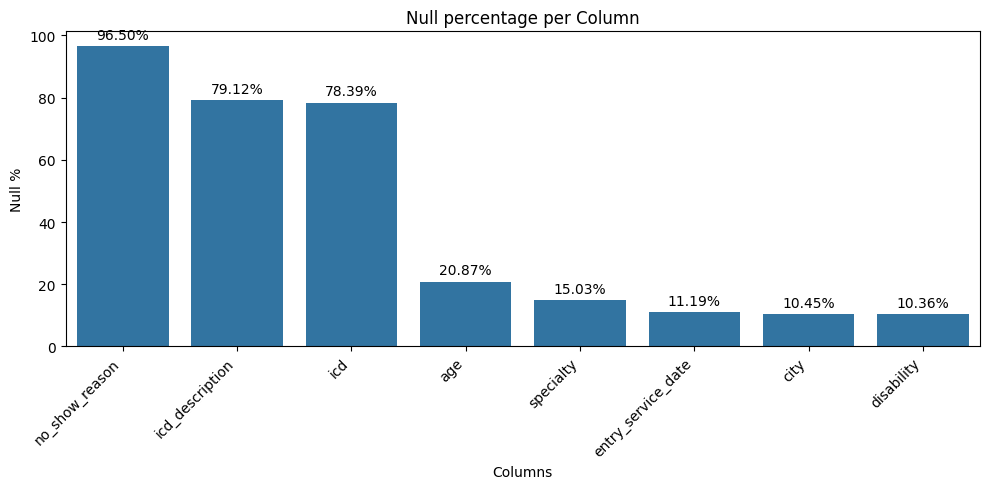

In [26]:
if not null_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=null_df.reset_index(), x="index", y="percentage", ax=ax)
    ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=3)
    plt.xticks(rotation=45, ha="right")
    plt.title("Null percentage per Column")
    plt.xlabel("Columns")
    plt.ylabel("Null %")
    plt.tight_layout()
    plt.show()

### 1.2 Class Imbalance (Target Variable)

C:\Users\Linek\AppData\Local\Temp\ipykernel_12564\581459333.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


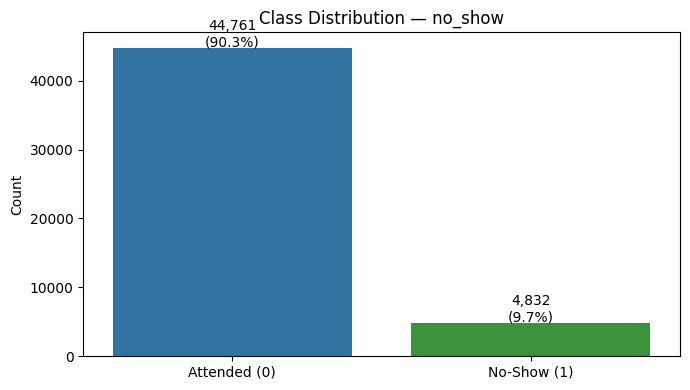


This directly impacts the choice of metrics in the modeling:
- Accuracy will be misleading (a model that predicts '0' would have 90% of accuracy)
- We must use F1-Score, ROC-AUC e Precision-Recall as the main metrics



In [27]:
if not data.empty:
    counts = data["no_show"].value_counts()
    pcts = data["no_show"].value_counts(normalize=True).round(3) * 100
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.barplot(
        x=["Attended (0)", "No-Show (1)"], y=counts.values, palette=["C0", "C2"], ax=ax
    )
    for i, (cnt, pct) in enumerate(zip(counts.values, pcts.values)):
        ax.text(i, cnt + 200, f"{cnt:,}\n({pct:.1f}%)", ha="center", fontsize=10)
    plt.title("Class Distribution — no_show")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

print("""
WARNING: The dataset is highly unbalanced (~90% attended vs ~10% no-show).
This directly impacts the choice of metrics in the modeling:
- Accuracy will be misleading (a model that predicts '0' would have 90% of accuracy)
- We must use F1-Score, ROC-AUC e Precision-Recall as the main metrics
""")

### 1.3 Inconsistent Dates

In [28]:
appt = pd.to_datetime(data["appointment_date"], errors="coerce")
entry = pd.to_datetime(data["entry_service_date"], errors="coerce")
inconsistent = (entry > appt).sum()
print(f"Records with entr_service_date AFTER appointment_date: {inconsistent}")

print(
    "These records have an inconsistency of origin (probable typing error at the clinic)"
)
print("They will be addressed in Feature Engineering before modeling")

Records with entr_service_date AFTER appointment_date: 827
These records have an inconsistency of origin (probable typing error at the clinic)
They will be addressed in Feature Engineering before modeling


### Conclusion — Data Quality

> - **`no_show_reason` (96.5% null)** e **`icd` (78.4% null)**: They cannot be used as reliable features in our model. Any analysis involving these columns should be interpreted with caution.
> - **`age` (20.9% null)**: Affects the demographic analysis. The age-group charts represent only ~79% of the patients
> - **Imbalance 90/10**: Expected for no_show problems. It Will be handled using specific techniques during modeling(ex: `class_weight`, SMOTE).
> - **827 inconsistent dates**: Valid for EDA, although they should be filtered out or corrected before the modeling process

## 2. Demographic Analysis

### 2.1 No-Show Count by Gender

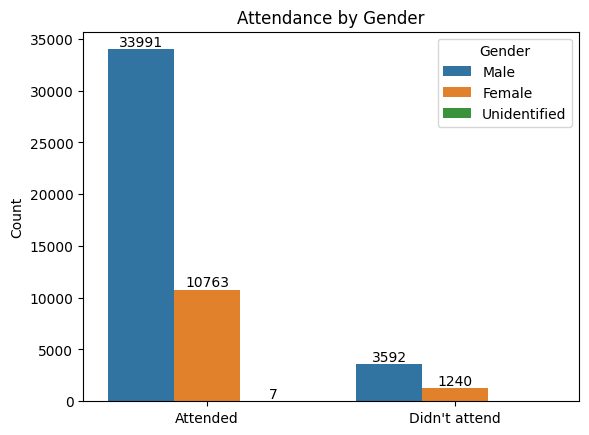

In [29]:
sns.countplot(data=data, x="no_show", hue="gender")
ax = plt.gca()
handles, _ = ax.get_legend_handles_labels()
labels = ["Male", "Female", "Unidentified"]
ax.legend(handles=handles, labels=labels, title="Gender")
plt.xticks(
    labels=["Attended", "Didn't attend"],
    ticks=[0, 1],
)
plt.xlabel("")
plt.ylabel("Count")
plt.title("Attendance by Gender")
for container in ax.containers:
    ax.bar_label(container, fmt="%d")
plt.show()

<h5>Total No-Show Volume By Gender</h5>

<p><b>Question:</b> What is the no-show volume by gender?</p>

<p><b>Findings:</b></p>
<ul>
    <li class="tab">
        <b>Female:</b> 1,240 no-shows out of 12,003 appointments
    </li>
    <li>
        <b>Male:</b> 3,592 no-shows out of 37,583 appointments
    </li>
</ul>

<p><b>Interpretation:</b></p> 
<p>Based on the total number of consultations by gender, we can observe that, in absolute terms, men attend more medical consultations than women. This suggests that, at least in this dataset, men tend to seek medical care more frequently than women. However, it is important to emphasize that this is only an initial observation, since the difference in the total number of consultations may be explained by the type of consultation. For example, the dataset may contain a higher proportion of consultation types that are more common among males.</p>

<p><b>Implication(s) for the model:</b></p> 
<p>This graph does not provide much information about the no-show rate itself, since the total volume distribution of a feature is generally not a strong metric for deciding whether a feature should be kept in the model. Disclaimer: this graph was used only to visualize the distribution difference between genders.</p>

### 2.1.2 - NoShow Rate By Gender

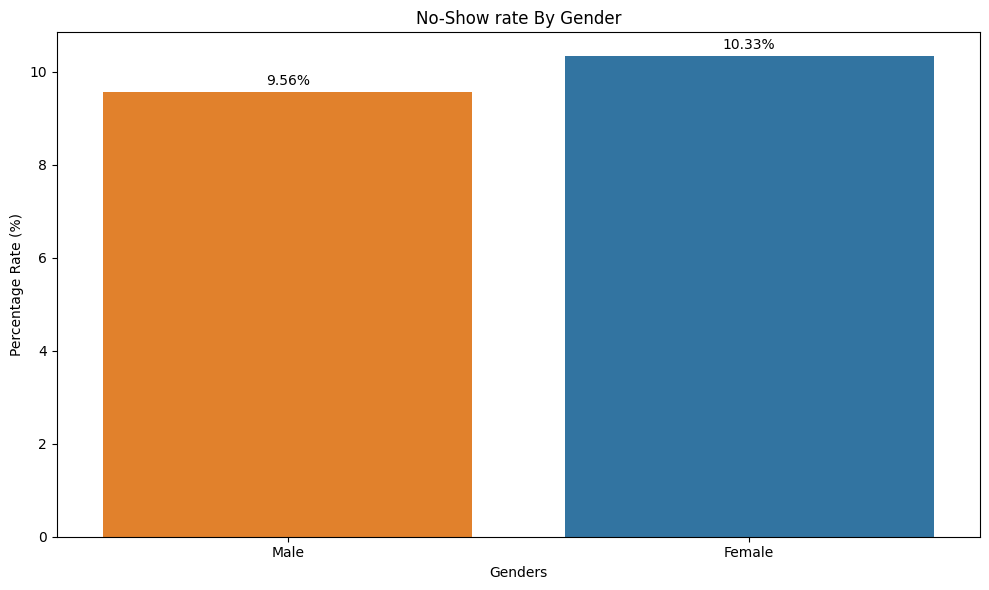

In [30]:
from matplotlib.container import BarContainer

df = data.loc[data["gender"].isin(["M", "F"])]
fig, ax = plt.subplots(figsize=(10, 6))

gender_rate = (
    df.groupby("gender")["no_show"]
    .mean()
    .mul(100)
    .round(2)
    .rename("rate")
    .reset_index()
)

sns.barplot(
    data=gender_rate,
    x="gender",
    y="rate",
    order=["M", "F"],
    hue="gender",
    ax=ax,
    legend=False,
)

for container in ax.containers:
    if isinstance(container, BarContainer):
        ax.bar_label(container, fmt="%.2f%%", padding=3)

ax.set_xticks([0, 1], ["Male", "Female"])
ax.set_title("No-Show rate By Gender")
ax.set_ylabel("Percentage Rate (%)")
ax.set_xlabel("Genders")
plt.tight_layout()
plt.show()

<h5>No-Show Rate By Gender</h5>

<p><b>Question:</b> Are there a relevant difference in the no-show rate by patient gender (male and female)?</p>

<p><b>Findings:</b></p>
<ul>
    <li class="tab">
        Female: 10.33% no-show rate
    </li>
    <li>
        Male: 9.56% no-show rate
    </li>
    <li>
        Difference: 0.77 percentage points
    </li>
</ul>

<p><b>Interpretation:</b> The percentage point difference is very similar (less than 1%), suggesting that gender is not a strong predictor of no-show behavior.</p>

<p><b>Implication(s) for the model:</b> Gender can be kept as a feature, although we should not expect a high level of importance from it. Possible non-linear or combined relationships with other features will be investigated through segmented visualizations.</p>

### 2.2 No-Show Rate by Age Group

C:\Users\Linek\AppData\Local\Temp\ipykernel_12564\1873442804.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(
C:\Users\Linek\AppData\Local\Temp\ipykernel_12564\1873442804.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_volume = data.groupby("age_group").size().reset_index(name="total")


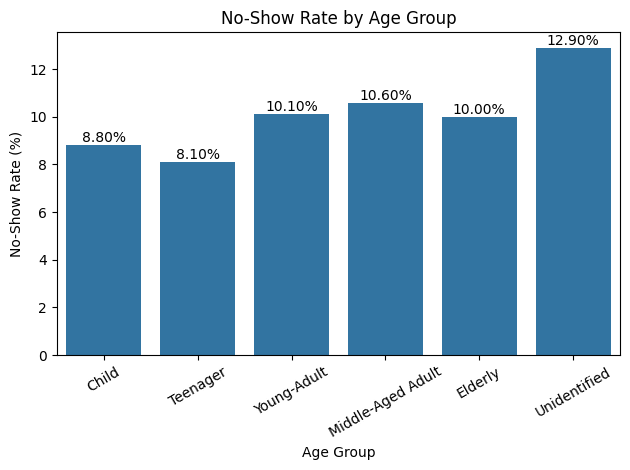

In [31]:
age_numeric = pd.to_numeric(data["age"], errors="coerce")
data["age_group"] = pd.cut(
    age_numeric,
    bins=[0, 12, 19, 39, 59],
    labels=["Child", "Teenager", "Young-Adult", "Middle-Aged Adult"],
)
data["age_group"] = data["age_group"].cat.add_categories(["Elderly", "Unidentified"])
data.loc[age_numeric >= 60, "age_group"] = "Elderly"
data.loc[pd.isna(age_numeric), "age_group"] = "Unidentified"

age_rate = (
    data.groupby(
        "age_group",
    )["no_show"]
    .mean()
    .reset_index(name="rate")
    .sort_values("rate", ascending=False)
)
age_volume = data.groupby("age_group").size().reset_index(name="total")
age_summary = age_rate.merge(age_volume, on="age_group")
age_summary["rate"] = round(age_summary["rate"], 3) * 100
ax = sns.barplot(data=age_summary, x="age_group", y="rate")
handles, _ = ax.get_legend_handles_labels()
labels = [
    "Child",
    "Teenager",
    "Young-Adult",
    "Middle-Aged Adult",
    "Elderly",
    "Unidentified",
]
if handles:
    ax.legend(handles=handles, labels=labels)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.title("No-Show Rate by Age Group")
plt.xticks(rotation=30)
plt.xlabel("Age Group")
plt.ylabel("No-Show Rate (%)")
plt.tight_layout()
plt.show()

<h5>No-Show Raty By Age Group<h5>

<p><b>Question:</b> Are there any relevant difference in no-show rate by agr group's ?</p>

<p>Findings:</b></p> 
<ul>
    <li class="tab">
        Total Amplitude: 4.10%  No-Show rate difference between Unidentified and Child.
    </li>
    <li>
        Total Valid Amplitude*: 1.8% -No-Show rate difference between indentified age groups'
    </li>
    <li>
        Teenagers tedns to miss fewer to appointments, while `unidentified` is the group who miss more to appointments.
    </li>
</ul>
<p><b>Interpretation:</b> The rates are somewhat dispersed, indicating a weak to moderate influence (depending on how we interpret the results). Although the rate difference is not so large in 'valid groups', when we include the `unidentified` group, something intersting is revealed: this group is composed of those who miss the most appointments, which could help the clinic to create a personalized service.
</p>

<p><b>Implications for the model:</b> We can keep the `age group` variable as an attribute of our model. We can expect some return from it, but not much, compared to "gender" and if we only consider "valid groups". However, with all age ranges, it becomes a good attribute. The decision to use it or not for all age ranges depends entirely on the business model and bussiness problem.
</p>

### Conclusion — Demographics

> All the features we have analyzed so far show valid candidates for our model, with special attention toward the age group feature, especially the `Unidentified` variable. This reveals something very important: patients who were not classified into an age group tend to miss appointments more often. The no-show rate amplitude is 4.10%, ranging from the lowest no-show rate in the `Teenager` group (8.10%) to the highest no-show rate in the `Unidentified` group (12.9%).

> This discovery alone points to `age group` as our most important feature so far.

> The no-show rate by gender reveals that, despite the difference in appointment volume between genders, the actual no-show rate difference is marginal (only 0.7%). Therefore, being male or female does not significantly impact whether a patient misses an appointment or not. However, we can still keep this feature in our model, although we should not expect it to have a major impact on the final result.

## 3. Temporal Analysis

### 3.1 No-Show Seasonality Along The year

C:\Users\Linek\AppData\Local\Temp\ipykernel_12564\2052946325.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby("appointment_month")["no_show"].mean().reset_index(name="rate")


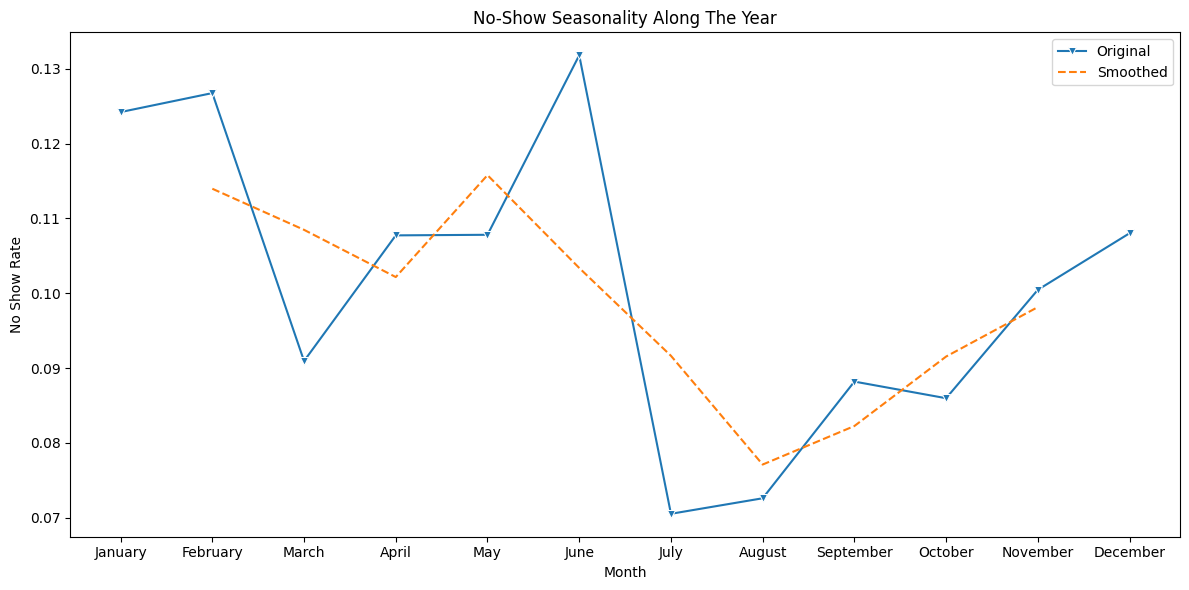

In [32]:
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December",
]

data["appointment_month"] = pd.to_datetime(
    data["appointment_date"], errors="coerce"
).dt.month_name()
data["appointment_month"] = pd.Categorical(
    data["appointment_month"], categories=month_order, ordered=True
)
monthly_rate = (
    data.groupby("appointment_month")["no_show"].mean().reset_index(name="rate")
)
monthly_rate["smooth"] = monthly_rate["rate"].rolling(3, center=True).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_rate, x="appointment_month", y="rate", marker="v", label="Original"
)
sns.lineplot(
    data=monthly_rate,
    x="appointment_month",
    y="smooth",
    linestyle="--",
    label="Smoothed",
)
plt.ylabel("No Show Rate")
plt.xlabel("Month")
plt.title("No-Show Seasonality Along The Year")
plt.tight_layout()
plt.show()

<h5>No-Show Seasonality Along The year</h5>

<p><b>Question:</b> Which period of the year do people miss appointments the most ?</p>

<p><b>Findings:</b></p>
<ul>
    <li class="tab">
        Variability: The first half of the year shows the highest no-show percentage rate, with a huge drop from June to July, followed by a gradual increase as the year progresses.
    </li>
    <li>
        The adjusted rate shows a more distributed change in the no-show rate.
    </li>
    <li>
        As expected, as we get closer to holidays, the no-show rate increases.
    </li>
</ul>

<p><b>Interpretation:</b> In the middle of the year, we can see the no-show rate dropping drastically compared to the previous months. The result we are seeing can be a consequence of the mid-year break, a period when schools and universities stop their operations for a few weeks, leading to a perfect time to schedule appointments.

As we get closer to the end-of-year holidays, the no-show rate starts to increase again. This time, we can interpret the increasing no-show rate as a consequence of families starting to travel to other places, states, and countries, reaching its peak in February then dropping in March just to increase again afterward.

This is the most common and logical interpretation, but we cannot ignore that the dataset ranges from 2016 to 2022. If we consider only the appointment year as context, there are 3 years in the dataset in which we were under a pandemic. This single factor can completely change the interpretation if we do not take this context into account.
</p>

<p><b>Implications for the model:</b>
    So far, the no-show seasonality throughout the year shows an interesting pattern to consider in our model, as we can observe behavioral changes depending on the period of the year in which an appointment is scheduled. However, this visualization is not yet well refined, since it does not take into account the different age groups in the dataset, which may reveal even more meaningful behavior patterns and potentially important features for the model. Therefore, we should not rely too heavily on this result yet, as we plan to create a more detailed and revealing analysis.
</p>


### 3.2 No-Show Rate by Sift.


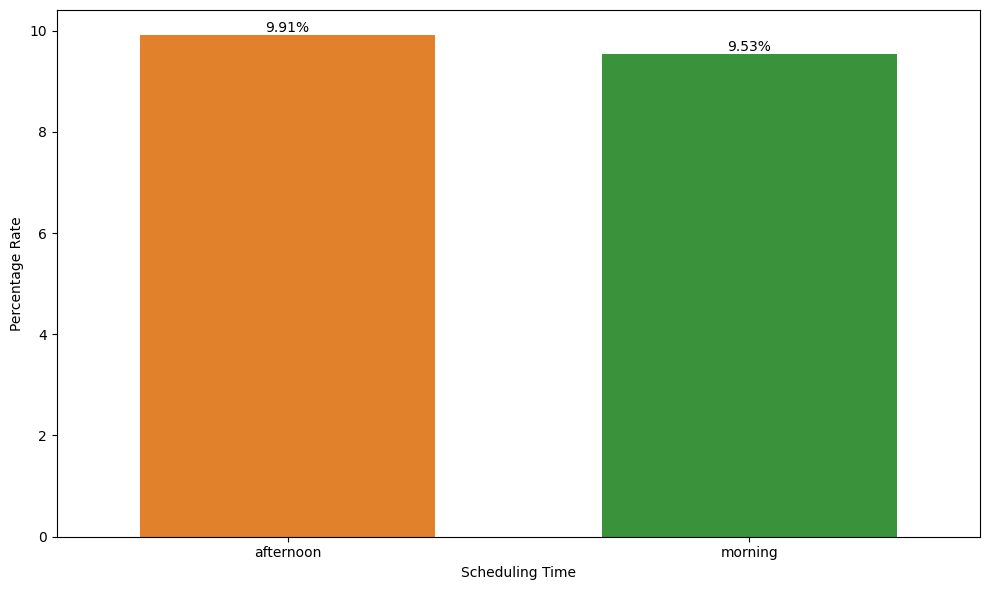

In [38]:
shift_time = (
    data.groupby(["appointment_shift"])["no_show"].mean().reset_index(name="rate")
)
shift_time["rate"] = round(shift_time["rate"] * 100, 2)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=shift_time,
    x="appointment_shift",
    y="rate",
    hue="appointment_shift",
    palette=["C1", "C2"],
    ax=ax,
    gap=0.2,
    legend=False,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")
ax.set_ylabel("Percentage Rate")
ax.set_xlabel("Scheduling Time")
plt.tight_layout()
plt.show()

<h5>No-Show rate by Shift</h5>

<p><b>Question:</b> Does the No-Show changes depending on shift ?</p>

<p><b>Findings:</b></p>
<ul>
    <li class="tab">
        Variability: Extremally low varibility from the shift time (0.38%)
    </li>
</ul>

<p><b>Interpretation:</b> The appoinment shift doesn't influence much on missing or not an appointment (almost nothing), suggesting that this feature is not a strong candidate to our model.
</p>

<p><b>Implications for the model:</b>
    The shift time doesn't showd itself as a good candidate to our model as the result of the charts shows that the difference in no_show rate its marginal, only 0.38%. By itself we could remove it from our model, altought it could be really usefull in a combined relationship.
</p>


### 3.2 No-Show Rate by Sift x Age.


C:\Users\Linek\AppData\Local\Temp\ipykernel_12564\3762622192.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(["appointment_shift", "age_group"])["no_show"]


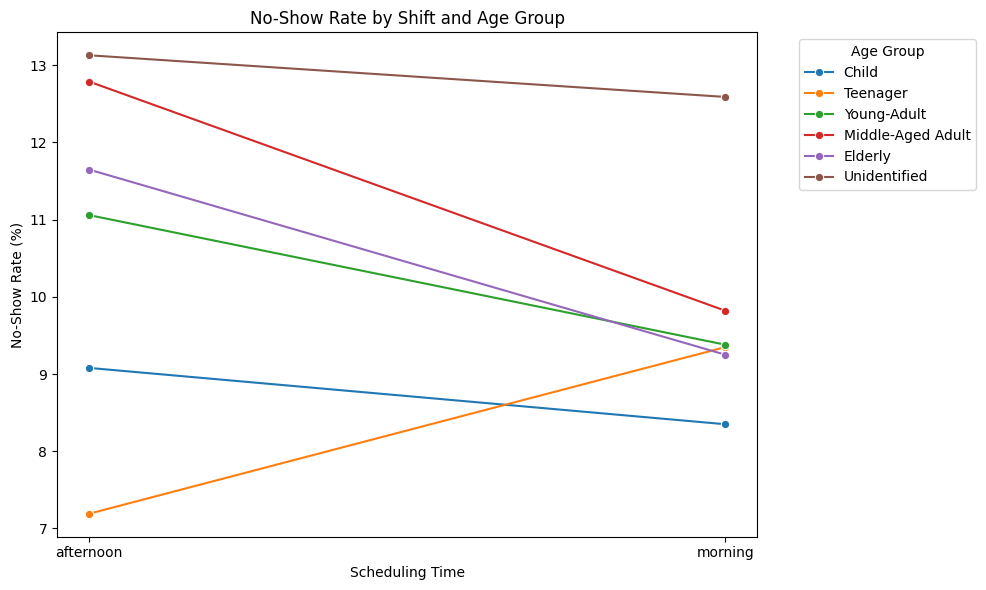

In [43]:
shift_time = (
    data.groupby(["appointment_shift", "age_group"])["no_show"]
    .mean()
    .reset_index(name="rate")
)
shift_time["rate"] = round(shift_time["rate"] * 100, 2)

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=shift_time,
    x="appointment_shift",
    y="rate",
    hue="age_group",
    ax=ax,
    marker="o",  # adiciona pontos nas linhas para clareza
)

ax.set_ylabel("No-Show Rate (%)")
ax.set_xlabel("Scheduling Time")
ax.set_title("No-Show Rate by Shift and Age Group")
ax.legend(title="Age Group", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

<h5>No-Show rate by Shift x Age Group </h5>

<p><b>Question:</b>
    <ul>
        <li class="tab"> Does the No-Show changes depending on shift ?</li>
        <li> Does this pattern changes by the age group ? </li>
    </ul>
</p>

<p><b>Findings:</b></p>
<ul>
    <li class="tab">
        Variability: Wee see a relevant chage in no_show rate depending on age group, with that wee can conclude that shift time its very important, enough do determine if someone will be missing an appointment.
    </li>
    <li>
        Middle-Aged-Adult, Young-Adult and Elderly the no_show rate of these 3 categories relatively drops as expected.
    </li>
    <li>
        Teenager no_show rate increases from afternoon to moorning.
    </li>
    <li>
        Child and Unidentified no_show rates gently drops from afternoon to moorning.
    </li>
</ul>

<p><b>Interpretation:</b> The appoinment shift doesn't influence much on missing or not an appointment (almost nothing), suggesting that this feature is not a strong candidate to our model.
</p>

<p><b>Implications for the model:</b>
    The shift time doesn't showd itself as a good candidate to our model as the result of the charts shows that the difference in no_show rate its marginal, only 0.38%. By itself we could remove it from our model, altought it could be really usefull in a combined relationship.
</p>


### Medical Analysis

In [ ]:
df = data[data["icd_description"].notna()]

top5 = df["icd_description"].value_counts().head(5).index
display(top5)

In [ ]:
icd_description_list = data["icd_description"].value_counts()
icd_description_list = icd_description_list[icd_description_list >= 100].index
df = data[data["icd_description"].isin(icd_description_list)]
df = (
    df.groupby("icd_description", as_index=False)["no_show"]
    .mean()
    .rename(columns={"no_show": "relation"})
    .sort_values(by="relation", ascending=False)
    .head(5)
)
df["relation"] = (df["relation"] * 100).round(2)
ax = plt.gca()

sns.barplot(data=df, x="icd_description", y="relation", gap=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%")

plt.xticks(rotation=90)
plt.xlabel("ICD Description")
plt.ylabel("Abscent Percentage Rate")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.show()

- Which days of the week do the most absent groups tend to be absent the most?

In [ ]:
mask = data[
    (data["age_group"] == "Unidentified")
    | (data["age_group"] == "Middle-Aged Adult")
    | (data["age_group"] == "Teenager")
].index
df2 = data.loc[mask, ["age_group", "day_of_the_week", "no_show", "appointment_shift"]]
df2["age_group"] = df2["age_group"].cat.remove_unused_categories()
df = (
    df2.groupby(["age_group", "day_of_the_week", "appointment_shift"], observed=True)[
        "no_show"
    ]
    .mean()
    .reset_index()
    .rename(columns={"no_show": "percentage"})
    .sort_values(by="percentage", ascending=False)
)
df["percentage"] = round(df["percentage"] * 100, 2)
g = sns.catplot(
    data=df,
    x="day_of_the_week",
    y="percentage",
    hue="age_group",
    col="appointment_shift",
    kind="bar",
    height=5,
    gap=0.3,
    aspect=1.4,
)
g.set_titles("{col_name}")

if g._legend is not None:
    g._legend.set_title("Age Group")
g.set_axis_labels("Day Of The Week", "Percentage Rate")

In [ ]:
data

In [ ]:
# data["gender"].replace({"M": "0", "F": "1", "I": np.nan}, inplace=True)
data[["appointment_shift_morning", "no_show"]].corr()